<a href="https://colab.research.google.com/github/edgnbusra/turkiye-konut-fiyat-tahmini/blob/main/Ev_Tahmini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Kütüphaneleri içe aktaralım
import pandas as pd              # Tablo ve veri işlemleri için
import numpy as np               # Matematiksel ve matris işlemleri için
import matplotlib.pyplot as plt  # Grafik çizdirmek için
import seaborn as sns            # Şık istatistiksel grafikler için

# 2. Hazır veri setini ve gerekli araçları çağıralım
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# 3. Kaliforniya konut veri setini yükleyelim
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [3]:
# Verinin ilk 5 satırına bakalım
display(df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# 3. Sütun isimleri ve veri tiplerini inceleyelim
print("\n--- Sütunlar ve Bilgileri ---")
df.info()


--- Sütunlar ve Bilgileri ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
# 2. Sütun isimlerini Türkçeleriyle değiştirelim
df = df.rename(columns={
    'MedInc': 'Medyan_Gelir',
    'HouseAge': 'Ev_Yasi',
    'AveRooms': 'Ortalama_Oda',
    'AveBedrms': 'Ortalama_Yatak_Odasi',
    'Population': 'Nufus',
    'AveOccup': 'Hane_Basi_Kisi_Sayisi',
    'Latitude': 'Enlem',
    'Longitude': 'Boylam',
    'MedHouseVal': 'Medyan_Ev_Fiyati'
})

# 3. İlk 5 satıra Türkçe başlıklarla bakalım
print("--- Türkçe Sütun İsimleriyle İlk 5 Satır ---")
display(df.head())

--- Türkçe Sütun İsimleriyle İlk 5 Satır ---


,Medyan_Gelir,Ev_Yasi,Ortalama_Oda,Ortalama_Yatak_Odasi,Nufus,Hane_Basi_Kisi_Sayisi,Enlem,Boylam,Medyan_Ev_Fiyati
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
# 4. Veriyi bağımsız değişkenler (X) ve hedef (y) olarak ayıralım
X = df.drop(columns=['Medyan_Ev_Fiyati'])  # Fiyat dışındaki özellikler
y = df['Medyan_Ev_Fiyati']                 # Ev fiyatı (Hedef)

In [7]:
# 5. Veriyi eğitim (%80) ve test (%20) olarak bölelim
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# 6. Doğrusal Regresyon modelini kuralım ve eğitelim
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
# 7. Test verisiyle tahmin yapalım
y_pred = model.predict(X_test);

In [10]:
# 8. Modelin başarı skorlarını ekrana yazdıralım
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [11]:
print(f"Hata Payı (MSE): {mse:.4f}")
print(f"Başarı Skoru (R2): {r2:.4f} (1'e ne kadar yakınsa o kadar iyi)")

Hata Payı (MSE): 0.5559
Başarı Skoru (R2): 0.5758 (1'e ne kadar yakınsa o kadar iyi)


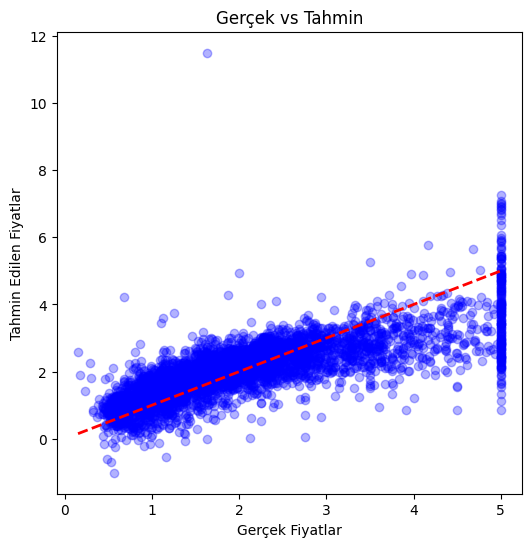

In [12]:
# 9. Gerçek ve tahmin edilen fiyatları görselleştirelim
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.xlabel("Gerçek Fiyatlar")
plt.ylabel("Tahmin Edilen Fiyatlar")
plt.title("Gerçek vs Tahmin")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.show()

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)
print("✅ Model başarıyla eğitildi ve tahmin için hazır!\n")

# 3. Kullanıcıdan Değer Alma (İnteraktif Tahmin Ekranı)
print("--- Lütfen Evin Özelliklerini Girin ---")
# Not: Veri seti genel ortalamalara dayalı olduğu için mantıklı aralıklarda değerler girebilirsin.

girilen_gelir = float(input("Bölgedeki Medyan Gelir (Örn: 3.5 veya 8.0): "))
girilen_yas = float(input("Evin Yaşı (Örn: 15 veya 30): "))
girilen_oda = float(input("Ortalama Oda Sayısı (Örn: 5.0): "))
girilen_yatak = float(input("Ortalama Yatak Odası Sayısı (Örn: 1.1): "))
girilen_nufus = float(input("Bölgedeki Nüfus (Örn: 1200): "))
girilen_kisi = float(input("Hane Başına Ortalama Kişi Sayısı (Örn: 2.5): "))
girilen_enlem = float(input("Enlem - Latitude (Örn: 34.0): "))
girilen_boylam = float(input("Boylam - Longitude (Örn: -118.0): "))

# Girilen değerleri modelin anlayacağı tablo (DataFrame) formatına getirelim
kullanici_verisi = pd.DataFrame([[
    girilen_gelir, girilen_yas, girilen_oda, girilen_yatak,
    girilen_nufus, girilen_kisi, girilen_enlem, girilen_boylam
]], columns=X.columns)

# 4. Tahmini Yapalım
tahmin_fiyat = model.predict(kullanici_verisi)[0]

# Veri setinde fiyatlar 100.000 dolar cinsindendir, daha anlaşılır yazdıralım:
gercek_tahmin_dolar = tahmin_fiyat * 100000

print("\n" + "="*40)
print(f"🏠 Modelin Tahmin Ettiği Ev Fiyatı: ${gercek_tahmin_dolar:,.2f}")
print("="*40)

✅ Model başarıyla eğitildi ve tahmin için hazır!

--- Lütfen Evin Özelliklerini Girin ---
Bölgedeki Medyan Gelir (Örn: 3.5 veya 8.0): 2
Evin Yaşı (Örn: 15 veya 30): 2
Ortalama Oda Sayısı (Örn: 5.0): 4
Ortalama Yatak Odası Sayısı (Örn: 1.1): 5
Bölgedeki Nüfus (Örn: 1200): 5
Hane Başına Ortalama Kişi Sayısı (Örn: 2.5): 8
Enlem - Latitude (Örn: 34.0): 8
Boylam - Longitude (Örn: -118.0): 8

🏠 Modelin Tahmin Ettiği Ev Fiyatı: $-3,954,027.33


Türkiye Ev tahmini

In [14]:
import json
import os

# Kaggle'ın beklediği yapı (username ve key içeren sözlük)
# Not: Kaggle API anahtarları genellikle 'username' ve 'key' ister.
# Eğer sadece bu anahtarı verdiyse, bunu doğrudan key olarak yazıp deneyebiliriz:
api_data = {"username": "YOUR_KAGGLE_USERNAME", "key": "KGAT_ce31745450e49afdeffebd96abed24c9"} # 'YOUR_KAGGLE_USERNAME' kısmını kendi Kaggle kullanıcı adınızla değiştirin!

# Klasörü oluşturalım
os.makedirs('/root/.kaggle', exist_ok=True)

# Dosyayı yazdıralım
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(api_data, f)

# İzinleri ayarlayalım
!chmod 600 /root/.kaggle/kaggle.json
print("✅ API anahtarı başarıyla kaydedildi!")

# 3. Şimdi veri setini doğrudan indirelim
!kaggle datasets download -d emrekaradag/real-estate-prices-in-turkey-2025

# 4. ZIP'ten çıkartalım
import zipfile
with zipfile.ZipFile('real-estate-prices-in-turkey-2025.zip', 'r') as zip_ref:
    zip_ref.extractall('turkiye_konut_verisi')

print("✅ Veri seti başarıyla indirildi!")

✅ API anahtarı başarıyla kaydedildi!
Dataset URL: https://www.kaggle.com/datasets/emrekaradag/real-estate-prices-in-turkey-2025
License(s): CC0-1.0
100% 112k/112k [00:00<00:00, 8.19MB/s]

✅ Veri seti başarıyla indirildi!


In [15]:
import pandas as pd
import os

# İndirdiğimiz klasörün içindeki dosyaları listeleyelim
dosyalar = os.listdir('turkiye_konut_verisi')
print(f"Klasördeki Dosyalar: {dosyalar}")

# .csv uzantılı dosyayı bulup Pandas ile okutalım
csv_dosyasi = [f for f in dosyalar if f.endswith('.csv')][0]
dosya_yolu = os.path.join('turkiye_konut_verisi', csv_dosyasi)

df = pd.read_csv(dosya_yolu)

# İlk 5 satıra bakalım
print("\n--- Veri Setinin İlk 5 Satırı ---")
display(df.head())

# Sütun isimlerine ve veri tiplerine genel bir bakalım
print("\n--- Veri Bilgileri ---")
df.info()

Klasördeki Dosyalar: ['processed_turkish_house_sales.csv']

--- Veri Setinin İlk 5 Satırı ---


,satici_tip,Metrekare,Oda_Sayisi,il,Ilce,Mahalle,Tarih,fiyat
0,Sahibinden,160.0,3.5+1,Istanbul,Şişli,Esentepe,25 Mayıs 2025,8750000
1,Sahibinden,85.0,2+1,Istanbul,Kartal,Topselvi,25 Mayıs 2025,4899000
2,Sahibinden,110.0,3+1,Istanbul,Tuzla,Aydınlı,24 Mayıs 2025,5900000
3,Sahibinden,200.0,6+1,Istanbul,Sultanbeyli,Necipfazıl,24 Mayıs 2025,6999999
4,Sahibinden,120.0,2+1,Istanbul,Esenyurt,Bilinmiyor,24 Mayıs 2025,1625000



--- Veri Bilgileri ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15276 entries, 0 to 15275
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   satici_tip  15276 non-null  object 
 1   Metrekare   15276 non-null  float64
 2   Oda_Sayisi  15276 non-null  object 
 3   il          15276 non-null  object 
 4   Ilce        15276 non-null  object 
 5   Mahalle     15276 non-null  object 
 6   Tarih       15276 non-null  object 
 7   fiyat       15276 non-null  int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 954.9+ KB


In [16]:
import pandas as pd

# 1. Oda Sayısı sütununu temizleyip sayısal hale getirelim
# Örn: "3+1" ifadesindeki sayıları toplayıp toplam oda sayısı yapalım (3 + 1 = 4)
def oda_temizle(deger):
    try:
        # Str'ye çevirip '+' işaretine göre bölelim ve sayıları toplayalım
        parcalar = str(deger).split('+')
        toplam = sum([int(p.strip()) for p in parcalar if p.strip().isdigit()])
        return toplam if toplam > 0 else 3 # Hatalı/boş olanlar için varsayılan 3
    except:
        return 3

# Fonksiyonu sütuna uygulayalım
df['Toplam_Oda'] = df['Oda_Sayisi'].apply(oda_temizle)

# 2. Modelde kullanacağımız sütunları sekelim (Örnek olarak: Metrekare, Toplam_Oda, il, Ilce, satici_tip)
# Mahalle çok fazla benzersiz içerik barındırdığı için şimdilik modele boğmamak adına dışarıda bırakıyoruz.
secilen_kolonlar = ['Metrekare', 'Toplam_Oda', 'il', 'Ilce', 'satici_tip']
X = df[secilen_kolonlar]
y = df['fiyat']

# 3. Kategorik sütunları One-Hot Encoding ile 0-1 sayısal matrisine çevirelim
# pd.get_dummies fonksiyonu metin sütunlarını otomatik olarak sayısal kolonlara parça parça ayırır.
X_encoded = pd.get_dummies(X, drop_first=True)

print("✅ Veri başarıyla sayısal formata dönüştürüldü!")
print(f"Eski sütun sayısı: {X.shape[1]} --> Yeni (Encoded) sütun sayısı: {X_encoded.shape[1]}")

# Dönüştürülmüş verinin ilk 5 satırına bir bakalım
display(X_encoded.head())

✅ Veri başarıyla sayısal formata dönüştürüldü!
Eski sütun sayısı: 5 --> Yeni (Encoded) sütun sayısı: 217


,Metrekare,Toplam_Oda,il_Ardahan,il_Artvin,il_Aydin,il_Bayburt,il_Bilecik,il_Bingol,il_Bursa,il_Canakkale,...,Ilce_İnhisar,Ilce_İpekyolu,Ilce_İscehisar,Ilce_İskenderun,Ilce_İznik,Ilce_Şavşat,Ilce_Şile,Ilce_Şişli,Ilce_Şuhut,satici_tip_Sahibinden
0,160.0,1,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
1,85.0,3,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,110.0,4,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,200.0,7,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,120.0,3,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Veriyi Eğitim (%80) ve Test (%20) olarak bölelim
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"Eğitim veri seti boyutu: {X_train.shape[0]} satır")
print(f"Test veri seti boyutu: {X_test.shape[0]} satır")

# 2. Modelimizi oluşturalım ve eğitelim
model = LinearRegression()
model.fit(X_train, y_train)
print("\n✅ Gerçek Türkiye Konut Modeli Başarıyla Eğitildi!")

# 3. Test verileriyle tahmin yapalım ve başarıyı ölçelim
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\n--- Model Performans Sonuçları ---")
print(f"R-Kare (R2) Skoru: {r2:.4f} (Modelin başarı oranı)")
print(f"Ortalama Hata Payı (MSE): {mse:,.2f}")

Eğitim veri seti boyutu: 12220 satır
Test veri seti boyutu: 3056 satır

✅ Gerçek Türkiye Konut Modeli Başarıyla Eğitildi!

--- Model Performans Sonuçları ---
R-Kare (R2) Skoru: 0.4057 (Modelin başarı oranı)
Ortalama Hata Payı (MSE): 6,179,937,398,045.79


In [18]:
import pandas as pd

# 1. Hangi şehirlerde veya ilçelerde tahmin yapmak istediğini görmek için örnekler verelim
print("--- Gerçek Veri Tabanlı Konut Fiyat Tahmin Paneli ---")
print(f"Mevcut Veri Setindeki İllerden Örnekler: {list(df['il'].unique()[:5])}")

# 2. Kullanıcıdan bilgileri alalım
girilen_il = input("İl Girin (Örn: İstanbul, Ankara, İzmir): ").strip()
girilen_ilce = input("İlçe Girin (Örn: Kadıköy, Çankaya, Bornova): ").strip()
girilen_satici = input("Satıcı Tipi Girin ('Sahibinden' veya 'Emlak Ofisinden'): ").strip()
girilen_net = float(input("Metrekare Girin (Örn: 120): "))
girilen_oda = int(input("Toplam Oda Sayısı Girin (Örn: 4): "))

# 3. Kullanıcının girdiği verileri modelin eğitimindeki sütun yapısına (X_encoded) uyduralım
# Önce boş bir satır oluşturalım
yeni_veri = pd.DataFrame(0, index=[0], columns=X_encoded.columns)

# Sayısal değerleri yerine koyalım
if 'Metrekare' in yeni_veri.columns:
    yeni_veri['Metrekare'] = girilen_net
if 'Toplam_Oda' in yeni_veri.columns:
    yeni_veri['Toplam_Oda'] = girilen_oda

# One-hot encoding sütunlarını (il, ilçe, satıcı tipi) doğru şekilde aktif edelim (1 yapalım)
il_kolon = f"il_{girilen_il}"
ilce_kolon = f"Ilce_{girilen_ilce}"
satici_kolon = f"satici_tip_{girilen_satici}"

if il_kolon in yeni_veri.columns:
    yeni_veri[il_kolon] = 1
if ilce_kolon in yeni_veri.columns:
    yeni_veri[ilce_kolon] = 1
if satici_kolon in yeni_veri.columns:
    yeni_veri[satici_kolon] = 1

# 4. Tahmini Yapalım
tahmin_fiyat = model.predict(yeni_veri)[0]

print("\n" + "="*45)
print(f"🇹🇷 Gerçek Veri Modeli Tahmini: {tahmin_fiyat:,.2f} TL")
print("="*45)

--- Gerçek Veri Tabanlı Konut Fiyat Tahmin Paneli ---
Mevcut Veri Setindeki İllerden Örnekler: ['Istanbul', 'Afyonkarahisar', 'Ardahan', 'Artvin', 'Aydin']
İl Girin (Örn: İstanbul, Ankara, İzmir): izmir 
İlçe Girin (Örn: Kadıköy, Çankaya, Bornova): çiğli 
Satıcı Tipi Girin ('Sahibinden' veya 'Emlak Ofisinden'): emlak ofisi 
Metrekare Girin (Örn: 120): 150
Toplam Oda Sayısı Girin (Örn: 4): 5

🇹🇷 Gerçek Veri Modeli Tahmini: 3,532,969.49 TL
